# Ocean Surface Temperature On A Curvilinear Grid

Create a CMIP7 monthly sea surface temperature file (`tos_tavg-u-hxy-sea`) using `cmor.grid` with two-dimensional latitude and longitude coordinates.

In [1]:
from pathlib import Path
import json
import shutil

import cmor
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import numpy as np
import xarray as xr

TABLES_DIR = "../cmip7-cmor-tables/tables"
CV_PATH = "../cmip7-cmor-tables/tables-cvs/cmor-cvs.json"
if not Path(TABLES_DIR).exists():
    raise FileNotFoundError(f"CMIP7 tables directory not found: {TABLES_DIR}")
if not Path(CV_PATH).exists():
    raise FileNotFoundError(f"CMIP7 CV file not found: {CV_PATH}")

print(f"Using CMIP7 tables from {TABLES_DIR}")


Using CMIP7 tables from ../cmip7-cmor-tables/tables


In [2]:
run_dir = Path("output") / "05_curvilinear_ocean_grid"
if run_dir.exists():
    shutil.rmtree(run_dir)
output_dir = run_dir / "cmor_output"
output_dir.mkdir(parents=True)

DATASET_INFO = {
    "_AXIS_ENTRY_FILE": "CMIP7_coordinate.json",
    "_FORMULA_VAR_FILE": "CMIP7_formula_terms.json",
    "_cmip7_option": 1,
    "_controlled_vocabulary_file": CV_PATH,
    "activity_id": "CMIP",
    "calendar": "360_day",
    "drs_specs": "MIP-DRS7",
    "experiment_id": "amip",
    "forcing_index": "f3",
    "frequency": "mon",
    "grid_label": "g999",
    "host_collection": "CMIP7",
    "initialization_index": "i1",
    "institution_id": "CCCma",
    "license_id": "CC-BY-4.0",
    "mip_era": "CMIP7",
    "nominal_resolution": "100 km",
    "outpath": str(output_dir),
    "physics_index": "p1",
    "realization_index": "r9",
    "region": "glb",
    "source_id": "DUMMY-MODEL",
    "tracking_prefix": "hdl:21.14107",
}
input_json = run_dir / "input.json"
input_json.write_text(json.dumps(DATASET_INFO, indent=2, sort_keys=True))

ny, nx = 18, 36
y = np.arange(ny, dtype="f8")
x = np.arange(nx, dtype="f8")
lat_centers = -85.0 + 10.0 * np.arange(ny, dtype="f8")
lon_centers = 5.0 + 10.0 * np.arange(nx, dtype="f8")
lon_grid, lat_grid = np.meshgrid(lon_centers, lat_centers)
latitude = np.clip(lat_grid + 1.5 * np.sin(np.deg2rad(lon_grid)) * np.cos(np.deg2rad(lat_grid)), -90.0, 90.0)
longitude = (lon_grid + 1.5 * np.sin(np.deg2rad(lat_grid))) % 360.0

lat_edges = -90.0 + 10.0 * np.arange(ny + 1, dtype="f8")
lon_edges = 10.0 * np.arange(nx + 1, dtype="f8")
latitude_vertices = np.empty((ny, nx, 4), dtype="f8")
longitude_vertices = np.empty((ny, nx, 4), dtype="f8")
for j in range(ny):
    for i in range(nx):
        corners = [
            (lat_edges[j], lon_edges[i]),
            (lat_edges[j], lon_edges[i + 1]),
            (lat_edges[j + 1], lon_edges[i + 1]),
            (lat_edges[j + 1], lon_edges[i]),
        ]
        for vertex, (lat_value, lon_value) in enumerate(corners):
            latitude_vertices[j, i, vertex] = np.clip(
                lat_value + 1.5 * np.sin(np.deg2rad(lon_value)) * np.cos(np.deg2rad(lat_value)),
                -90.0,
                90.0,
            )
            longitude_vertices[j, i, vertex] = (lon_value + 1.5 * np.sin(np.deg2rad(lat_value))) % 360.0

time = 15.0 + 30.0 * np.arange(2, dtype="f8")
time_bnds = 30.0 * np.arange(3, dtype="f8")
time_units = "days since 2018-01-01"

seasonal_cycle = np.array([0.0, 0.8], dtype="f4")[:, None, None]
tos = (
    15.0
    - 25.0 * np.sin(np.deg2rad(latitude))[None, :, :] ** 2
    + 1.5 * np.cos(np.deg2rad(longitude))[None, :, :]
    + seasonal_cycle
).astype("f4")

tos.shape


(2, 18, 36)

In [3]:
cmor.setup(
    inpath=TABLES_DIR,
    netcdf_file_action=cmor.CMOR_REPLACE,
    logfile=str(run_dir / "cmor.log"),
)
cmor.dataset_json(str(input_json))

grid_table = cmor.load_table("CMIP7_grids.json")
ocean_table = cmor.load_table("CMIP7_ocean.json")

cmor.set_table(grid_table)
y_id = cmor.axis("y", coord_vals=y, units="m")
x_id = cmor.axis("x", coord_vals=x, units="m")
grid_id = cmor.grid(
    axis_ids=[y_id, x_id],
    latitude=latitude,
    longitude=longitude,
    latitude_vertices=latitude_vertices,
    longitude_vertices=longitude_vertices,
)

cmor.set_table(ocean_table)
time_id = cmor.axis("time", coord_vals=time, cell_bounds=time_bnds, units=time_units)

variable_name = "tos_tavg-u-hxy-sea"
tos_id = cmor.variable(variable_name, "degC", [time_id, grid_id])
compound_name = ".".join(["ocean"] + variable_name.split("_") + ["mon", "glb"])

with open(Path(TABLES_DIR) / "CMIP7_cell_measures.json") as handle:
    cell_measure = json.load(handle)["cell_measures"].get(compound_name)
if cell_measure:
    cmor.set_variable_attribute(tos_id, "cell_measures", "c", cell_measure)

with open(Path(TABLES_DIR) / "CMIP7_long_name_overrides.json") as handle:
    long_name = json.load(handle)["long_name_overrides"].get(compound_name)
if long_name:
    cmor.set_variable_attribute(tos_id, "long_name", "c", long_name)

cmor.write(tos_id, tos)
netcdf_path = Path(cmor.close(tos_id, file_name=True))
cmor.close()

netcdf_path.resolve().relative_to(Path.cwd().resolve())


PosixPath('output/05_curvilinear_ocean_grid/cmor_output/MIP-DRS7/CMIP7/CMIP/CCCma/DUMMY-MODEL/amip/r9i1p1f3/glb/mon/tos/tavg-u-hxy-sea/g999/v20260529/tos_tavg-u-hxy-sea_mon_glb_g999_DUMMY-MODEL_amip_r9i1p1f3_201801-201802.nc')

In [4]:
with xr.open_dataset(netcdf_path, decode_times=False) as opened:
    ds = opened.load()
ds


<xarray.Dataset> Size: 58kB
Dimensions:             (time: 2, bnds: 2, y: 18, x: 36, vertices: 4)
Coordinates:
  * time                (time) float64 16B 15.0 45.0
  * y                   (y) float64 144B 0.0 1.0 2.0 3.0 ... 14.0 15.0 16.0 17.0
  * x                   (x) float64 288B 0.0 1.0 2.0 3.0 ... 32.0 33.0 34.0 35.0
    latitude            (y, x) float64 5kB -84.99 -84.97 -84.94 ... 84.97 84.99
    longitude           (y, x) float64 5kB 3.506 13.51 23.51 ... 346.5 356.5
Dimensions without coordinates: bnds, vertices
Data variables:
    time_bnds           (time, bnds) float64 32B 0.0 30.0 30.0 60.0
    vertices_latitude   (y, x, vertices) float64 21kB -90.0 -90.0 ... 90.0 90.0
    vertices_longitude  (y, x, vertices) float64 21kB 358.5 8.5 ... 1.5 351.5
    tos                 (time, y, x) float32 5kB -8.312 -8.349 ... -7.549 -7.512
Attributes: (12/40)
    Conventions:           CF-1.12
    activity_id:           CMIP
    area_label:            sea
    branded_variable:      tos_tavg-u-hxy-sea
    branding_suffix:       tavg-u-hxy-sea
    creation_date:         2026-05-29T22:05:23Z
    ...                    ...
    tracking_id:           hdl:21.14107/12b4876d-52a9-44eb-b35c-251f776908a6
    variable_id:           tos
    variant_label:         r9i1p1f3
    vertical_label:        u
    license:               CC-BY-4.0; CMIP7 data produced by CCCma is license...
    cmor_version:          3.15.1

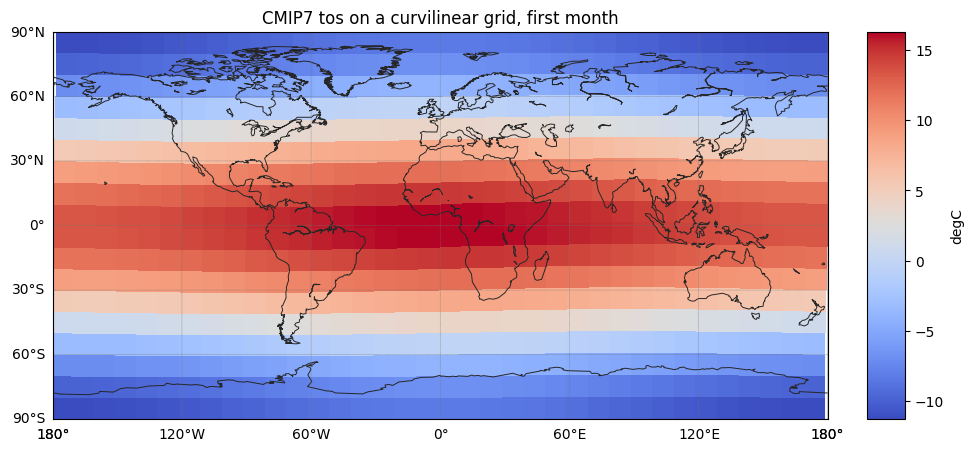

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.4))
map_plot = Basemap(
    projection="cyl",
    llcrnrlon=-180,
    urcrnrlon=180,
    llcrnrlat=-90,
    urcrnrlat=90,
    resolution="c",
    ax=ax,
)
map_plot.drawmapboundary(fill_color="#f7fbff", linewidth=0.8)
longitude_wrapped = ((ds["longitude"].values + 180.0) % 360.0) - 180.0
x_order = np.argsort(longitude_wrapped.mean(axis=0))
x, y = map_plot(longitude_wrapped[:, x_order], ds["latitude"].values[:, x_order])
field = ds["tos"].isel(time=0).values[:, x_order]
mesh = map_plot.pcolormesh(x, y, field, shading="auto", cmap="coolwarm")
map_plot.drawcoastlines(linewidth=0.7, color="0.15")
map_plot.drawparallels(np.arange(-90, 91, 30), labels=[1, 0, 0, 0], linewidth=0.4, color="0.45", dashes=[1, 1])
map_plot.drawmeridians(np.arange(-180, 181, 60), labels=[0, 0, 0, 1], linewidth=0.4, color="0.45", dashes=[1, 1])
colorbar = map_plot.colorbar(mesh, location="right", pad="5%")
colorbar.set_label("degC")
ax.set_title("CMIP7 tos on a curvilinear grid, first month")
plt.show()
